# Support Vector Classifier (SVC): Robustní klasifikátor s jádrovými funkcemi

## Co je Support Vector Classifier?

Support Vector Classifier (SVC) je výkonný algoritmus strojového učení používaný pro klasifikaci. Je založen na konceptu hledání optimální nadroviny, která maximalizuje okraj (margin) mezi třídami v prostoru příznaků. SVC je částí rodiny algoritmů Support Vector Machines (SVM).

### Klíčové koncepty SVC:

1. **Nadroviná (Hyperplane)**: Rozdělující hranice mezi třídami
2. **Okraj (Margin)**: Vzdálenost mezi nadrovinou a nejbližšími body (tzv. podpůrnými vektory)
3. **Podpůrné vektory (Support Vectors)**: Data body, které leží nejblíže k rozhodovací hranici
4. **Jádrový trik (Kernel Trick)**: Transformace dat do vyšší dimenze, kde jsou lineárně oddělitelná
5. **Regularizační parametr C**: Kontroluje kompromis mezi hladkou rozhodovací hranicí a správnou klasifikací trénovacích bodů

### Kdy použít SVC:

- Pro nelineární klasifikační problémy
- Pro datové sady střední velikosti (do cca 10,000 vzorků)
- Když potřebujete robustní model vůči odlehlým hodnotám
- Když je důležitá kvalita predikce více než interpretovatelnost modelu
- Když pracujete s problémy, kde je počet příznaků větší než počet vzorků

### Výhody SVC:

- Efektivní ve vysokodimenzionálních prostorech
- Různé jádrové funkce pro různé typy problémů
- Paměťově efektivní (používá pouze podmnožinu trénovacích bodů)
- Robustní vůči přeučení ve vysokých dimenzích
- Dobrá teoretická základna a pochopení

### Nevýhody SVC:

- Špatná škálovatelnost pro velké datasety (kvadratická složitost)
- Citlivost na volbu parametrů, zejména typu jádra a jeho parametrů
- Náročná interpretovatelnost modelu
- Není přímo vhodný pro úlohy s více třídami (řeší se 'one-versus-one' nebo 'one-versus-rest')

Pojďme nyní implementovat a prozkoumat SVC na reálných datech.

In [1]:
# Import potřebných knihoven
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import warnings

# Potlačení varování
warnings.filterwarnings('ignore')

# Nastavení pro reprodukovatelnost výsledků
np.random.seed(42)

# Nastavení stylů pro grafy
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Načtení a prozkoumání datové sady

Pro demonstraci SVC použijeme dataset rakoviny prsu z knihovny scikit-learn, který obsahuje příznaky vypočtené z digitálních snímků jader buněk z prsní tkáně. Cílem je klasifikovat nádory jako maligní (zhoubné) nebo benigní (nezhoubné).

In [2]:
# Načtení datasetu rakoviny prsu
data = load_breast_cancer()
X = data.data
y = data.target

# Základní informace o datasetu
print(f"Tvar dat: {X.shape}")
print(f"Počet tříd: {len(np.unique(y))}")
print(f"Názvy tříd: {data.target_names}")
print(f"Rozložení tříd: {np.bincount(y)}")

# Vytvoření DataFrame pro lepší manipulaci s daty
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['diagnosis'] = y

# Zobrazení prvních několika řádků dat
print("\nUkázka dat:")
print(df.head())

# Statistický souhrn dat
print("\nStatistický souhrn:")
print(df.describe().T)

Tvar dat: (569, 30)
Počet tříd: 2
Názvy tříd: ['malignant' 'benign']
Rozložení tříd: [212 357]

Ukázka dat:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430    

### Vizuální průzkum dat

Podíváme se na distribuci některých příznaků rozdělených podle diagnózy. Pro komplexní datasety jako je tento, je důležité pochopit, jak se jednotlivé příznaky liší mezi třídami.

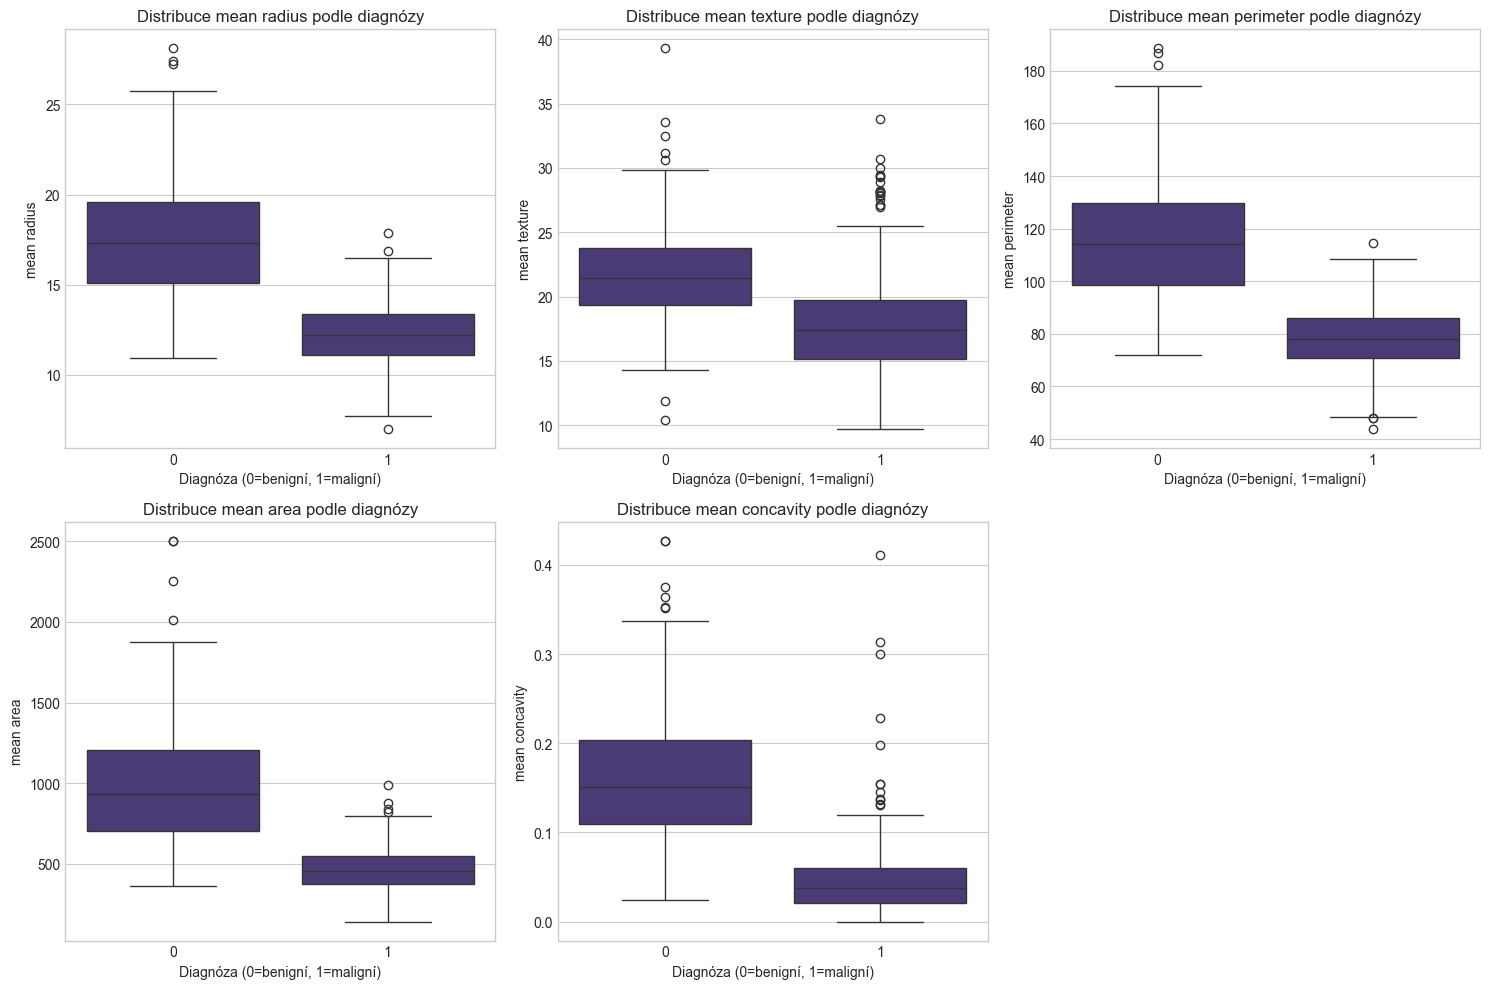

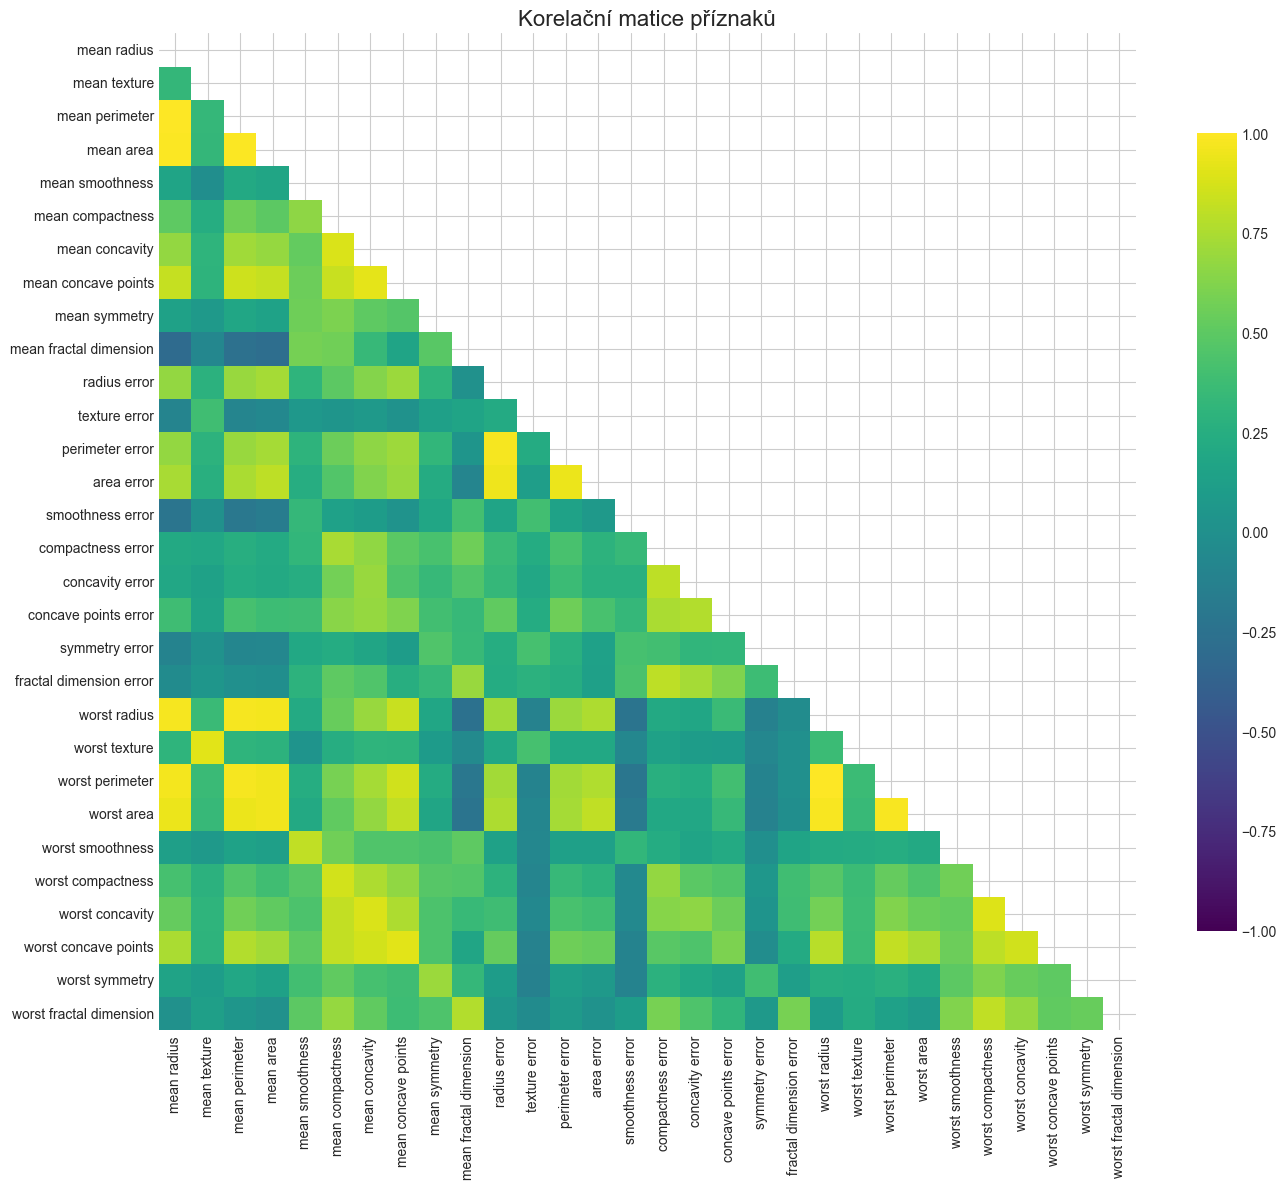

In [3]:
# Vizualizace distribuce příznaků podle diagnózy
plt.figure(figsize=(15, 10))

# Vybereme několik zajímavých příznaků pro vizualizaci
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean concavity']

for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='diagnosis', y=feature, data=df)
    plt.title(f'Distribuce {feature} podle diagnózy')
    plt.xlabel('Diagnóza (0=benigní, 1=maligní)')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

# Korelační matice příznaků
plt.figure(figsize=(14, 12))
corr = df.iloc[:, :-1].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='viridis', vmax=1, vmin=-1, cbar_kws={"shrink": .8})
plt.title('Korelační matice příznaků', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Příprava dat pro modelování

Před trénováním modelu SVC je důležité data připravit. SVC je citlivý na měřítko příznaků, takže je vhodné data standardizovat. Rozdělíme data na trénovací a testovací množinu.

In [4]:
# Rozdělení dat na trénovací a testovací množinu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Standardizace dat
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Trénovací data: {X_train_scaled.shape}")
print(f"Testovací data: {X_test_scaled.shape}")
print(f"Rozložení tříd v trénovacích datech: {np.bincount(y_train)}")
print(f"Rozložení tříd v testovacích datech: {np.bincount(y_test)}")

Trénovací data: (426, 30)
Testovací data: (143, 30)
Rozložení tříd v trénovacích datech: [159 267]
Rozložení tříd v testovacích datech: [53 90]


## 3. Implementace základního modelu SVC

Začneme s jednoduchým modelem SVC s výchozími parametry, abychom stanovili základní výkon.

Přesnost základního SVC: 0.9790

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.96      0.98      0.97        53
      benign       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



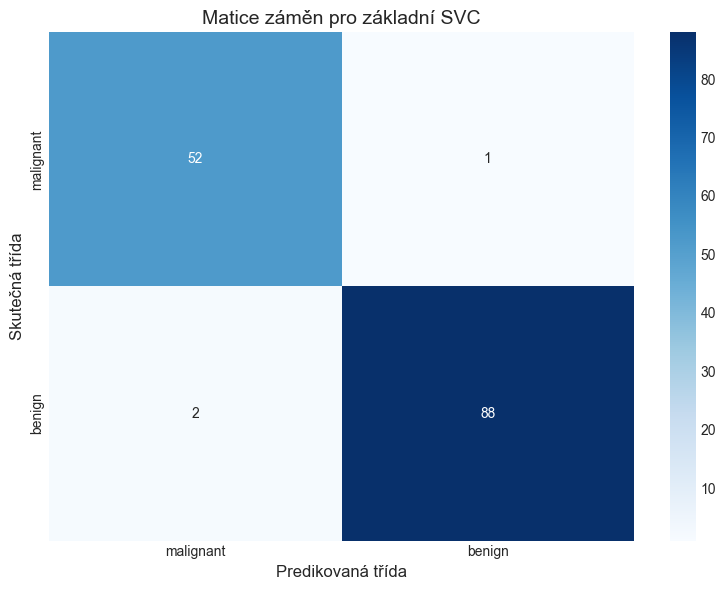

In [5]:
# Trénování základního modelu SVC
svc = SVC(random_state=42)
svc.fit(X_train_scaled, y_train)

# Predikce na testovacích datech
y_pred = svc.predict(X_test_scaled)

# Vyhodnocení výkonu
accuracy = accuracy_score(y_test, y_pred)
print(f"Přesnost základního SVC: {accuracy:.4f}")
print("\nKlasifikační report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Matice záměn
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Matice záměn pro základní SVC', fontsize=14)
plt.ylabel('Skutečná třída', fontsize=12)
plt.xlabel('Predikovaná třída', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Porovnání různých jádrových funkcí

SVC nabízí několik typů jádrových funkcí, které transformují data do vyšších dimenzí, kde mohou být lineárně oddělitelná. Porovnáme výkon nejběžnějších jader.

Jádro: linear, Přesnost: 0.9860
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143

--------------------------------------------------
Jádro: poly, Přesnost: 0.9021
              precision    recall  f1-score   support

   malignant       1.00      0.74      0.85        53
      benign       0.87      1.00      0.93        90

    accuracy                           0.90       143
   macro avg       0.93      0.87      0.89       143
weighted avg       0.92      0.90      0.90       143

--------------------------------------------------
Jádro: rbf, Přesnost: 0.9790
              precision    recall  f1-score   support

   malignant       0.96      0.98      0.97        53
      benign       0.99      0.98      0.98 

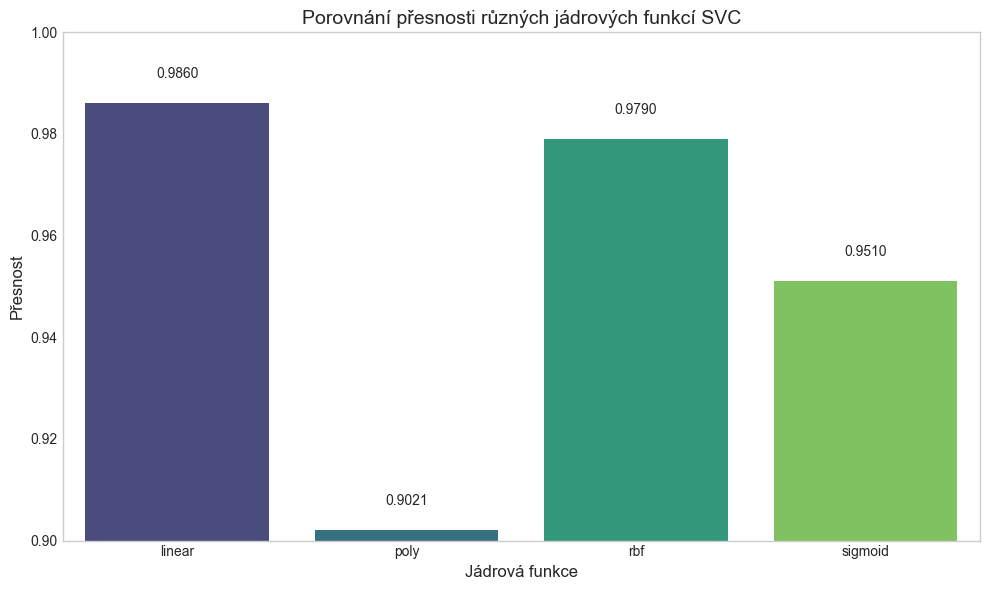

In [6]:
# Seznam jádrových funkcí k porovnání
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_scores = []

for kernel in kernels:
    # Vytvoření a trénování SVC s aktuálním jádrem
    svc = SVC(kernel=kernel, random_state=42)
    svc.fit(X_train_scaled, y_train)
    
    # Predikce a vyhodnocení
    y_pred = svc.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    kernel_scores.append((kernel, accuracy))
    
    print(f"Jádro: {kernel}, Přesnost: {accuracy:.4f}")
    print(classification_report(y_test, y_pred, target_names=data.target_names))
    print("-" * 50)

# Vizualizace výsledků
kernels, scores = zip(*kernel_scores)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(kernels), y=list(scores), palette='viridis')
plt.title('Porovnání přesnosti různých jádrových funkcí SVC', fontsize=14)
plt.xlabel('Jádrová funkce', fontsize=12)
plt.ylabel('Přesnost', fontsize=12)
plt.ylim(0.90, 1.0)  # Nastavení rozsahu pro lepší vizualizaci rozdílů
plt.grid(axis='y')

# Přidání hodnot nad sloupce
for i, score in enumerate(scores):
    plt.text(i, score + 0.005, f'{score:.4f}', ha='center')

plt.tight_layout()
plt.show()

## 5. Optimalizace hyperparametrů pomocí GridSearchCV

Nyní provedeme systematické hledání nejlepších hyperparametrů pro SVC. Zaměříme se na parametr regularizace C, gamma pro RBF jádro a stupeň pro polynomiální jádro.

Spouštím optimalizaci hyperparametrů...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Nejlepší parametry: {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Nejlepší cross-validation skóre: 0.9671

Přesnost optimalizovaného SVC na testovacích datech: 0.9860

Klasifikační report pro optimalizovaný model:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



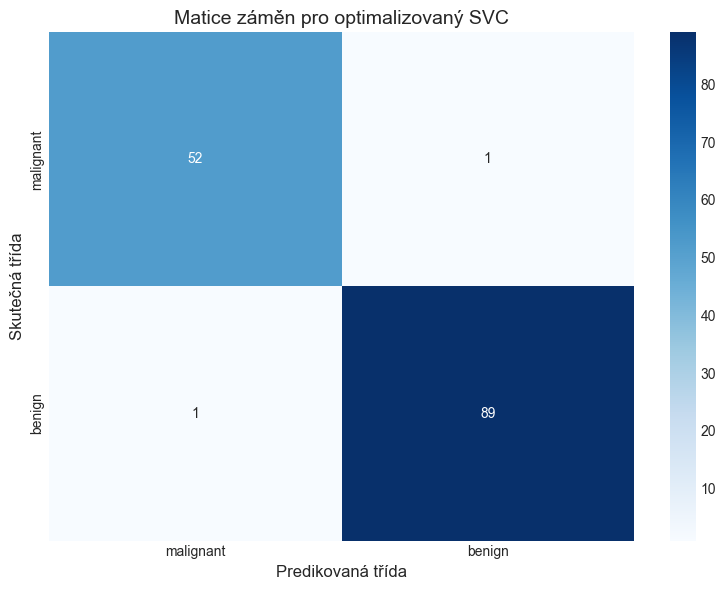

In [7]:
# Vytvoření pipeline pro standardizaci a SVC
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])

# Definice prostoru parametrů pro GridSearch
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 'auto', 0.1, 1],
    'svc__kernel': ['rbf', 'linear']
}

# Inicializace GridSearchCV
grid_search = GridSearchCV(
    pipeline, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)

# Spuštění prohledávání
print("Spouštím optimalizaci hyperparametrů...")
grid_search.fit(X_train, y_train)

# Zobrazení nejlepších parametrů
print(f"\nNejlepší parametry: {grid_search.best_params_}")
print(f"Nejlepší cross-validation skóre: {grid_search.best_score_:.4f}")

# Vyhodnocení nejlepšího modelu na testovacích datech
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print(f"\nPřesnost optimalizovaného SVC na testovacích datech: {accuracy_best:.4f}")
print("\nKlasifikační report pro optimalizovaný model:")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

# Matice záměn pro optimalizovaný model
plt.figure(figsize=(8, 6))
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Matice záměn pro optimalizovaný SVC', fontsize=14)
plt.ylabel('Skutečná třída', fontsize=12)
plt.xlabel('Predikovaná třída', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Vizualizace rozhodovacích hranic

Pro lepší pochopení, jak SVC klasifikuje data, zobrazíme jeho rozhodovací hranice na dvourozměrné projekci dat pomocí PCA.

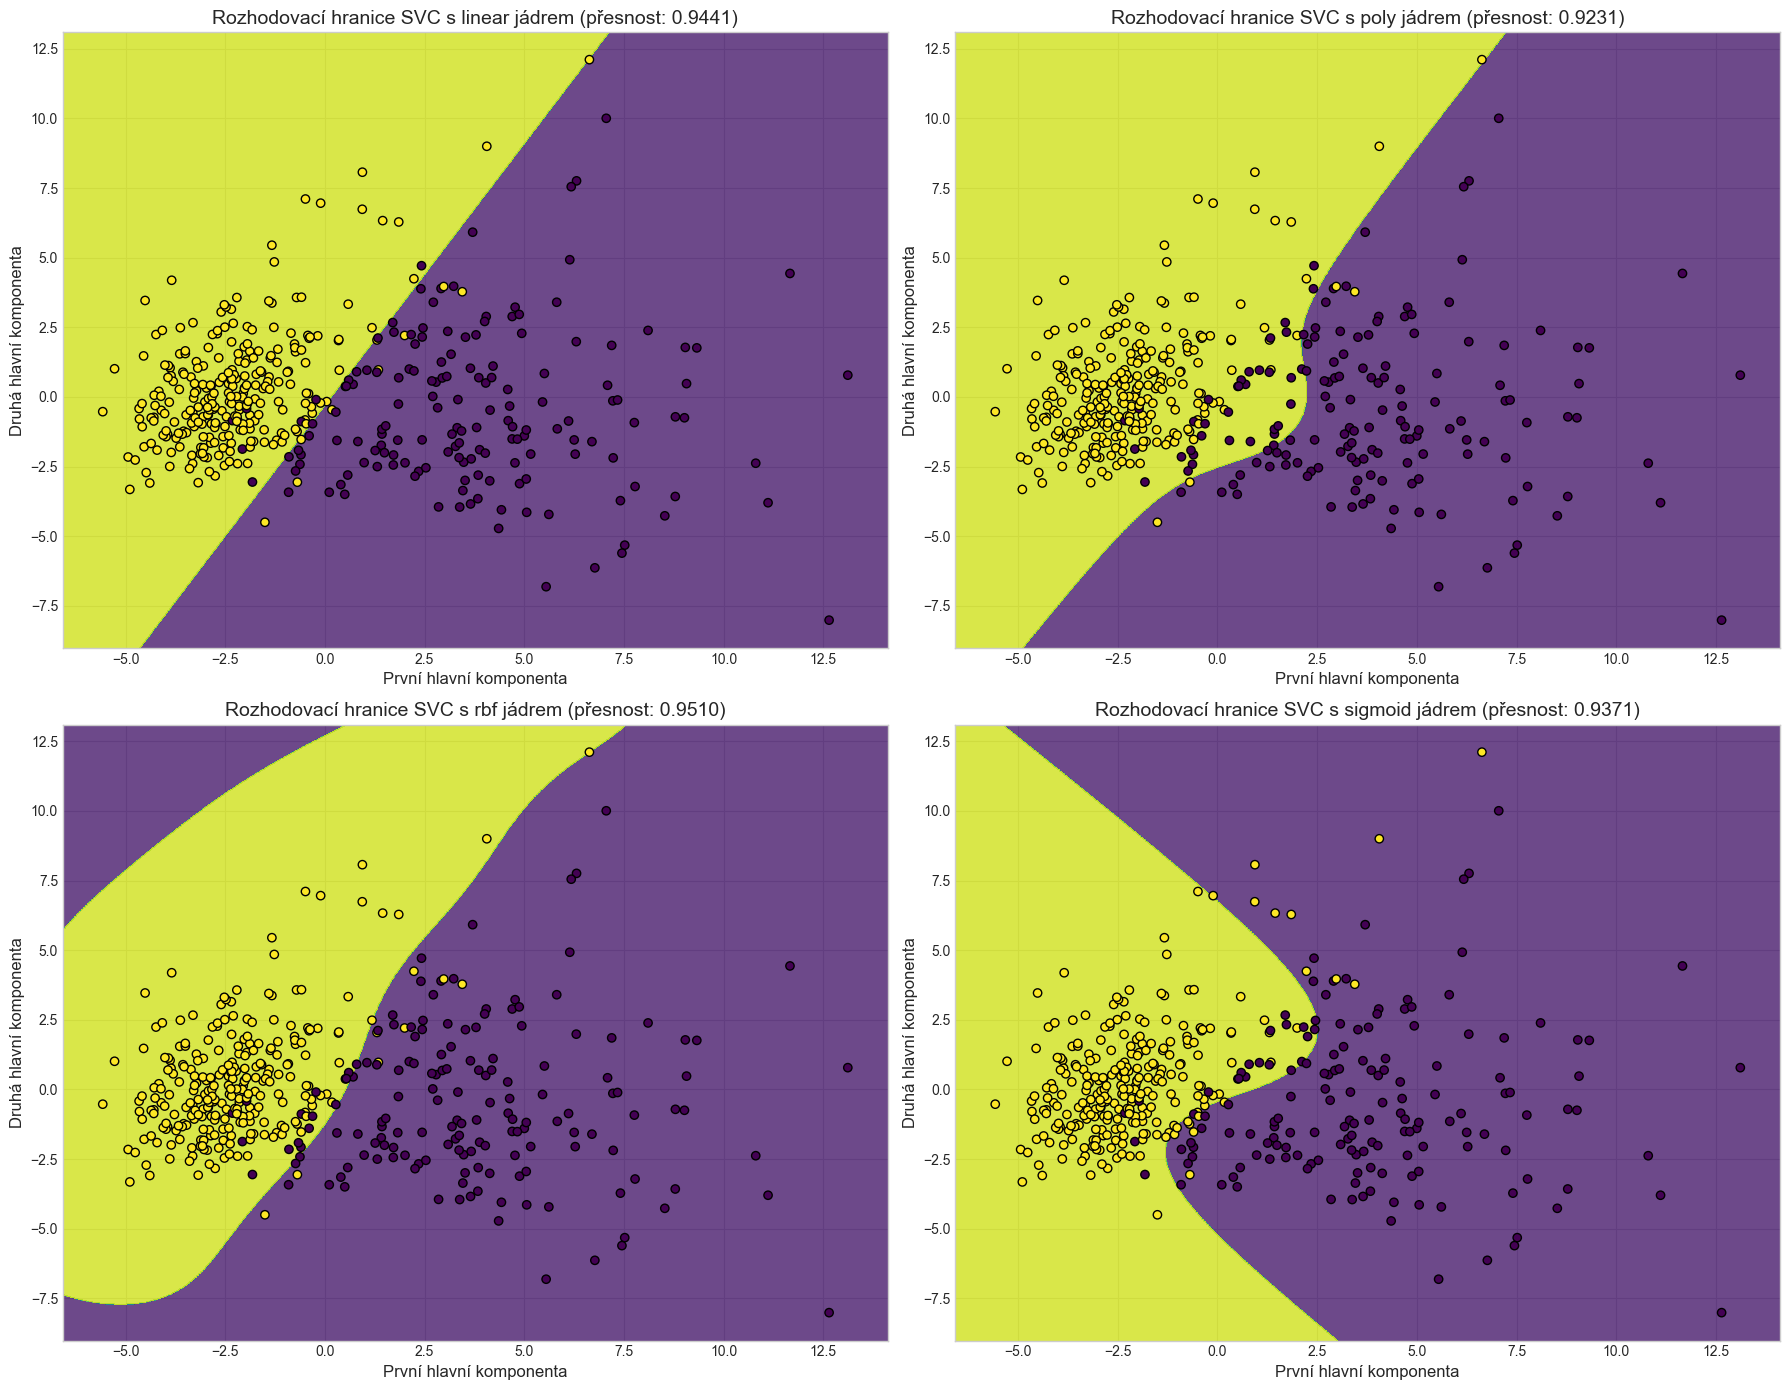

<Figure size 1200x1000 with 0 Axes>

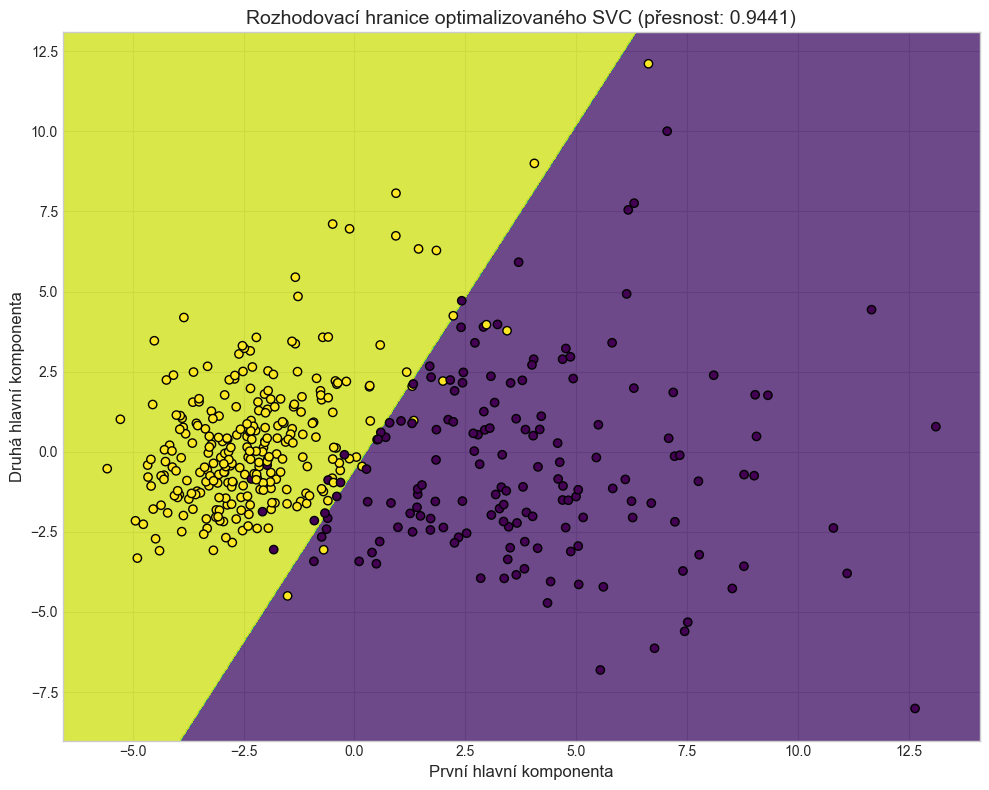

In [8]:
# Funkce pro vykreslení rozhodovacích hranic
def plot_decision_boundaries(X, y, model, title, ax=None):
    h = .02  # krok v mřížce
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Predikce pro každý bod mřížky
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    if ax is None:
        plt.figure(figsize=(10, 8))
        ax = plt.gca()
        
    # Vykreslení rozhodovacích hranic a datových bodů
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.viridis)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.viridis, edgecolor='k')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('První hlavní komponenta', fontsize=12)
    ax.set_ylabel('Druhá hlavní komponenta', fontsize=12)
    return ax

# Redukce dimenzionality na 2D pro vizualizaci
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Vykreslení rozhodovacích hranic pro různé typy jádrových funkcí
plt.figure(figsize=(18, 14))
kernels_to_plot = ['linear', 'poly', 'rbf', 'sigmoid']

for i, kernel in enumerate(kernels_to_plot):
    # Trénování SVC s aktuálním jádrem na 2D datech
    svc_2d = SVC(kernel=kernel, random_state=42)
    svc_2d.fit(X_train_pca, y_train)
    
    # Predikce a výpočet přesnosti
    y_pred_2d = svc_2d.predict(X_test_pca)
    accuracy_2d = accuracy_score(y_test, y_pred_2d)
    
    # Vykreslení
    ax = plt.subplot(2, 2, i+1)
    plot_decision_boundaries(X_train_pca, y_train, svc_2d, 
                             f"Rozhodovací hranice SVC s {kernel} jádrem (přesnost: {accuracy_2d:.4f})", ax=ax)

plt.tight_layout()
plt.show()

# Vykreslení nejlepšího modelu z GridSearch na 2D datech
# Nejprve musíme znovu natrénovat model s nejlepšími parametry na 2D datech
best_params = grid_search.best_params_
best_kernel = best_params['svc__kernel']
best_C = best_params['svc__C']
best_gamma = best_params['svc__gamma']

best_svc_2d = SVC(kernel=best_kernel, C=best_C, gamma=best_gamma, random_state=42)
best_svc_2d.fit(X_train_pca, y_train)
y_pred_best_2d = best_svc_2d.predict(X_test_pca)
accuracy_best_2d = accuracy_score(y_test, y_pred_best_2d)

plt.figure(figsize=(12, 10))
plot_decision_boundaries(X_train_pca, y_train, best_svc_2d, 
                        f"Rozhodovací hranice optimalizovaného SVC (přesnost: {accuracy_best_2d:.4f})")
plt.tight_layout()
plt.show()

## 7. Vliv parametru C na výkon modelu

Parametr C kontroluje kompromis mezi hladkou rozhodovací hranicí a správnou klasifikací trénovacích bodů. Podíváme se, jak různé hodnoty C ovlivňují výkon modelu.

C=0.001: Trénovací přesnost=0.6268, Testovací přesnost=0.6294, Počet podpůrných vektorů=318
C=0.01: Trénovací přesnost=0.6268, Testovací přesnost=0.6294, Počet podpůrných vektorů=320
C=0.1: Trénovací přesnost=0.9624, Testovací přesnost=0.9371, Počet podpůrných vektorů=191
C=1: Trénovací přesnost=0.9789, Testovací přesnost=0.9790, Počet podpůrných vektorů=96
C=10: Trénovací přesnost=0.9930, Testovací přesnost=0.9790, Počet podpůrných vektorů=78
C=100: Trénovací přesnost=1.0000, Testovací přesnost=0.9441, Počet podpůrných vektorů=67
C=1000: Trénovací přesnost=1.0000, Testovací přesnost=0.9441, Počet podpůrných vektorů=67


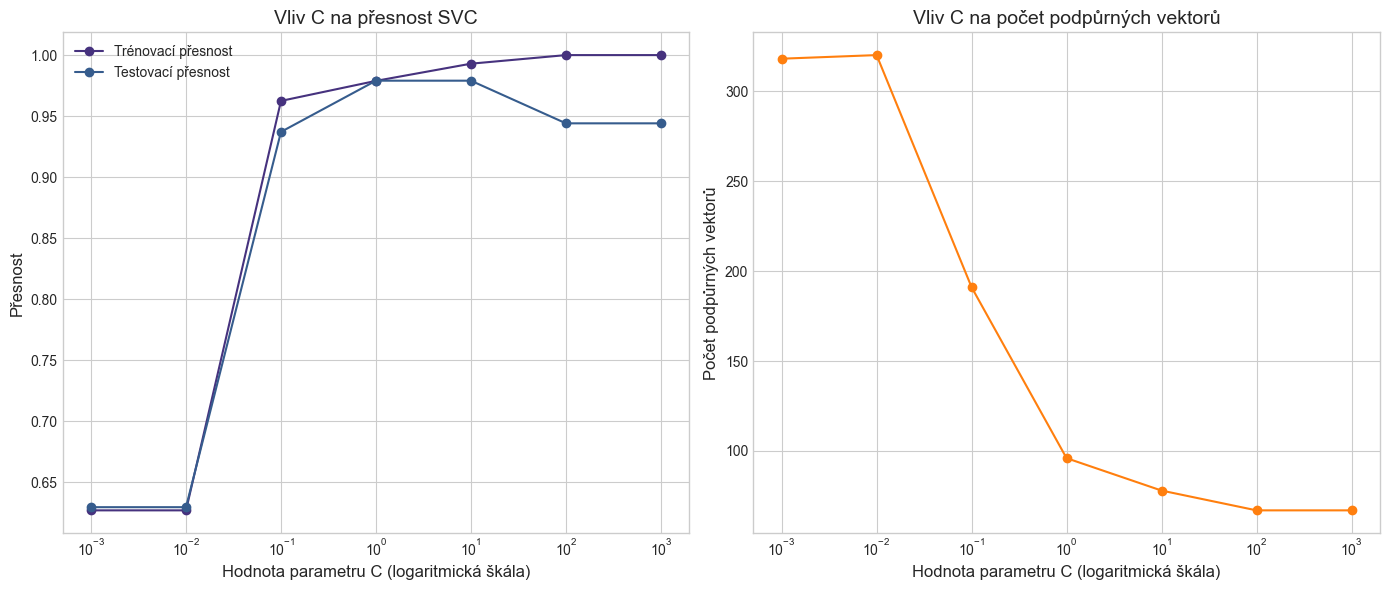

In [9]:
# Testování různých hodnot parametru C
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_scores = []
test_scores = []
support_vectors = []

for C in C_values:
    # Trénování SVC s aktuální hodnotou C
    svc = SVC(C=C, kernel='rbf', gamma='scale', random_state=42)
    svc.fit(X_train_scaled, y_train)
    
    # Zaznamenání počtu podpůrných vektorů
    n_sv = svc.n_support_.sum()
    support_vectors.append(n_sv)
    
    # Vyhodnocení na trénovacích a testovacích datech
    train_score = svc.score(X_train_scaled, y_train)
    test_score = svc.score(X_test_scaled, y_test)
    
    train_scores.append(train_score)
    test_scores.append(test_score)
    
    print(f"C={C}: Trénovací přesnost={train_score:.4f}, Testovací přesnost={test_score:.4f}, Počet podpůrných vektorů={n_sv}")

# Vizualizace výsledků
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.semilogx(C_values, train_scores, 'o-', label='Trénovací přesnost')
plt.semilogx(C_values, test_scores, 'o-', label='Testovací přesnost')
plt.xlabel('Hodnota parametru C (logaritmická škála)', fontsize=12)
plt.ylabel('Přesnost', fontsize=12)
plt.title('Vliv C na přesnost SVC', fontsize=14)
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.semilogx(C_values, support_vectors, 'o-', color='#ff7f0e')
plt.xlabel('Hodnota parametru C (logaritmická škála)', fontsize=12)
plt.ylabel('Počet podpůrných vektorů', fontsize=12)
plt.title('Vliv C na počet podpůrných vektorů', fontsize=14)
plt.grid(True)

plt.tight_layout()
plt.show()

## 8. Vliv parametru gamma pro RBF jádro

Parametr gamma určuje, jak daleko sahá vliv jednoho trénovacího příkladu. Nízké hodnoty znamenají větší vliv na větší vzdálenost (hladší rozhodovací hranice), zatímco vysoké hodnoty gamma znamenají vliv pouze na blízké body.

gamma=0.0001: Trénovací přesnost=0.7911, Testovací přesnost=0.7832
gamma=0.001: Trénovací přesnost=0.9531, Testovací přesnost=0.9441
gamma=0.01: Trénovací přesnost=0.9789, Testovací přesnost=0.9720
gamma=0.1: Trénovací přesnost=0.9859, Testovací přesnost=0.9720
gamma=1: Trénovací přesnost=1.0000, Testovací přesnost=0.6294
gamma=10: Trénovací přesnost=1.0000, Testovací přesnost=0.6294
gamma=100: Trénovací přesnost=1.0000, Testovací přesnost=0.6294


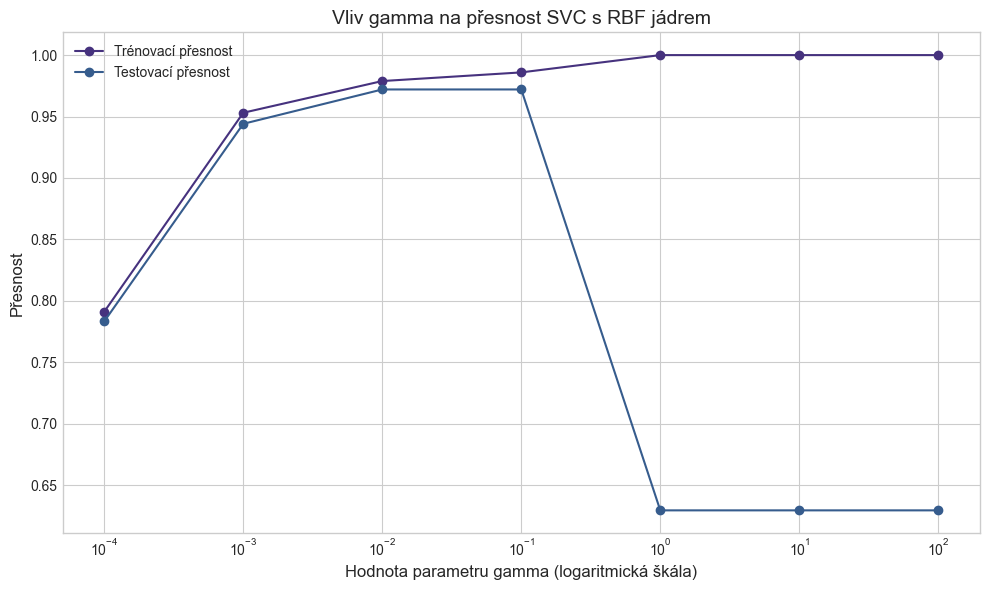

In [10]:
# Testování různých hodnot parametru gamma
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
train_scores_gamma = []
test_scores_gamma = []

for gamma in gamma_values:
    # Trénování SVC s aktuální hodnotou gamma
    svc = SVC(C=1.0, kernel='rbf', gamma=gamma, random_state=42)
    svc.fit(X_train_scaled, y_train)
    
    # Vyhodnocení na trénovacích a testovacích datech
    train_score = svc.score(X_train_scaled, y_train)
    test_score = svc.score(X_test_scaled, y_test)
    
    train_scores_gamma.append(train_score)
    test_scores_gamma.append(test_score)
    
    print(f"gamma={gamma}: Trénovací přesnost={train_score:.4f}, Testovací přesnost={test_score:.4f}")

# Vizualizace výsledků
plt.figure(figsize=(10, 6))
plt.semilogx(gamma_values, train_scores_gamma, 'o-', label='Trénovací přesnost')
plt.semilogx(gamma_values, test_scores_gamma, 'o-', label='Testovací přesnost')
plt.xlabel('Hodnota parametru gamma (logaritmická škála)', fontsize=12)
plt.ylabel('Přesnost', fontsize=12)
plt.title('Vliv gamma na přesnost SVC s RBF jádrem', fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Křivky učení

Křivky učení zobrazují výkon modelu jako funkci velikosti trénovacího datasetu. Pomáhají odhalit, zda model trpí vysokou variancí (přeučení) nebo vysokým zkreslením (podučení).

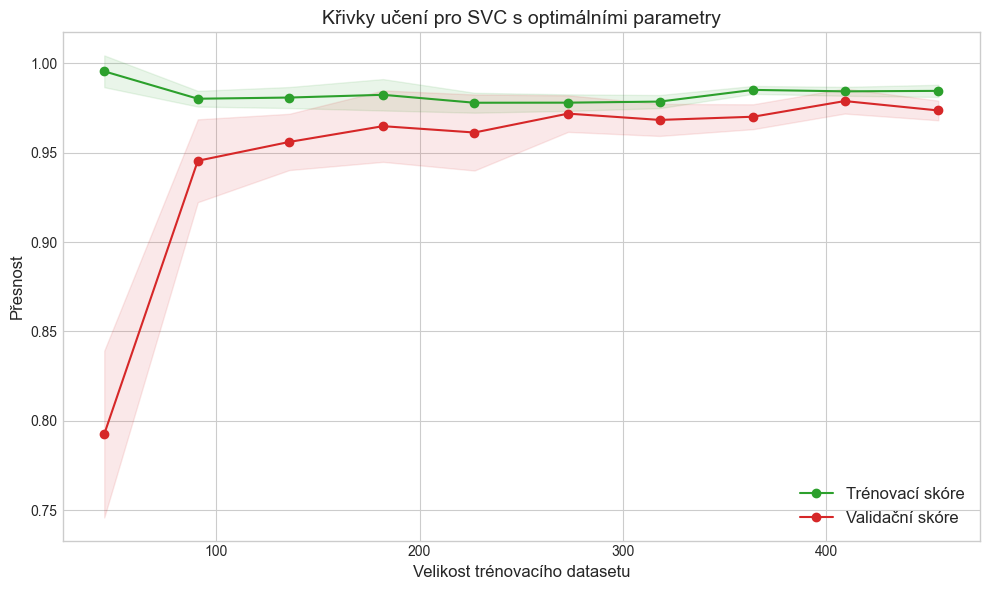

In [11]:
# Vytvoření pipeline pro křivky učení
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel=best_kernel, C=best_C, gamma=best_gamma, random_state=42))
])

# Výpočet křivek učení
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=pipe, X=X, y=y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1, random_state=42
)

# Výpočet průměrů a směrodatných odchylek
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
validation_mean = np.mean(validation_scores, axis=1)
validation_std = np.std(validation_scores, axis=1)

# Vykreslení křivek učení
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#2ca02c', label='Trénovací skóre')
plt.plot(train_sizes, validation_mean, 'o-', color='#d62728', label='Validační skóre')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#2ca02c')
plt.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, alpha=0.1, color='#d62728')
plt.xlabel('Velikost trénovacího datasetu', fontsize=12)
plt.ylabel('Přesnost', fontsize=12)
plt.title('Křivky učení pro SVC s optimálními parametry', fontsize=14)
plt.grid(True)
plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Srovnání SVC s jinými klasifikátory

Pro kontext porovnáme výkon SVC s jinými běžnými klasifikátory.

In [12]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.tree import DecisionTreeClassifier

# # Seznam klasifikátorů pro srovnání
# classifiers = [
#     ('SVC (optimalizovaný)', SVC(kernel=best_kernel, C=best_C, gamma=best_gamma, random_state=42)),
#     ('Random Forest', RandomForestClassifier(random_state=42)),
#     ('Logistická regrese', LogisticRegression(random_state=42, max_iter=1000)),
#     ('KNN', KNeighborsClassifier(n_neighbors=5)),
#     ('Rozhodovací strom', DecisionTreeClassifier(random_state=42))
# ]

# # Srovnání pomocí cross-validace
# results = []
# for name, clf in classifiers:
#     # Vytvoření pipeline s klasifikátorem
#     pipe = Pipeline([
#         ('scaler', StandardScaler()),
#         ('classifier', clf)
#     ])
    
#     # Cross-validace
#     cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
#     results.append((name, cv_scores.mean(), cv_scores.std()))
#     print(f"{name}: Průměrná přesnost = {cv_scores.mean():.4f}, Směr. odchylka = {cv_scores.std():.4f}")

# # Vizualizace výsledků
# names, means, stds = zip(*results)
# plt.figure(figsize=(12, 6))
# bars = plt.barh(names, means, xerr=stds, color='viridis')

# # Přidání hodnot na konec pruhů
# for i, bar in enumerate(bars):
#     plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{means[i]:.4f}',
#              va='center', fontsize=10)

# plt.xlabel('Průměrná přesnost (5-fold CV)', fontsize=12)
# plt.title('Srovnání klasifikátorů', fontsize=14)
# plt.xlim(0.85, 1.0)  # Nastavení rozsahu pro lepší vizualizaci rozdílů
# plt.grid(axis='x')
# plt.tight_layout()
# plt.show()

```
ValueError: 'facecolor' or 'color' argument must be a valid color orsequence of colors.
```

SVC (optimalizovaný): Průměrná přesnost = 0.9719, Směr. odchylka = 0.0086
Random Forest: Průměrná přesnost = 0.9561, Směr. odchylka = 0.0228
Logistická regrese: Průměrná přesnost = 0.9807, Směr. odchylka = 0.0065
KNN: Průměrná přesnost = 0.9649, Směr. odchylka = 0.0096
Rozhodovací strom: Průměrná přesnost = 0.9173, Směr. odchylka = 0.0242


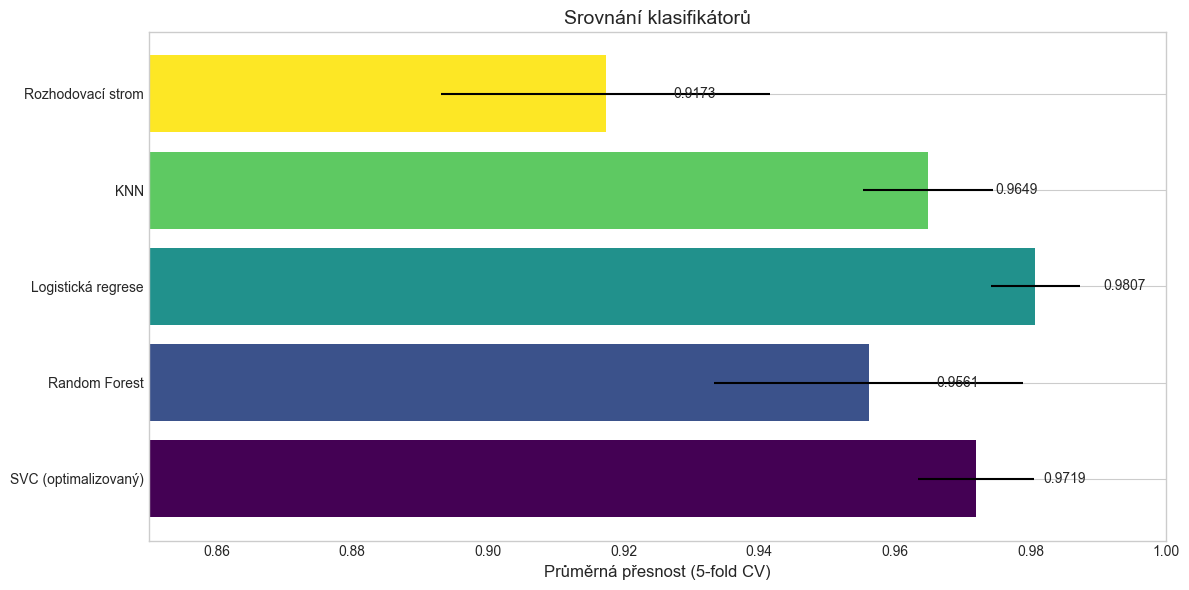

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# List of classifiers for comparison
classifiers = [
    ('SVC (optimalizovaný)', SVC(kernel='linear', C=1, gamma='scale', random_state=42)),  # Example parameters
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Logistická regrese', LogisticRegression(random_state=42, max_iter=1000)),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('Rozhodovací strom', DecisionTreeClassifier(random_state=42))
]

# Comparison using cross-validation
results = []
for name, clf in classifiers:
    # Create a pipeline with a classifier
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', clf)
    ])
    
    # Cross-validation
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    results.append((name, cv_scores.mean(), cv_scores.std()))
    print(f"{name}: Průměrná přesnost = {cv_scores.mean():.4f}, Směr. odchylka = {cv_scores.std():.4f}")

# Visualization of results
names, means, stds = zip(*results)
plt.figure(figsize=(12, 6))

# Using a colormap for the bars
colors = plt.cm.viridis(np.linspace(0, 1, len(names)))

bars = plt.barh(names, means, xerr=stds, color=colors)

# Adding values to the end of the bars
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{means[i]:.4f}',
             va='center', fontsize=10)

plt.xlabel('Průměrná přesnost (5-fold CV)', fontsize=12)
plt.title('Srovnání klasifikátorů', fontsize=14)
plt.xlim(0.85, 1.0)  # Setting the range for better visualization of differences
plt.grid(axis='x')
plt.tight_layout()
plt.show()

## 11. Vytvoření syntetického datasetu pro ukázku lineárně neoddělitelných dat

Vytvoříme syntetický dataset, kde data nejsou lineárně oddělitelná, abychom lépe pochopili, jak SVC s různými jádry funguje na takových datech.

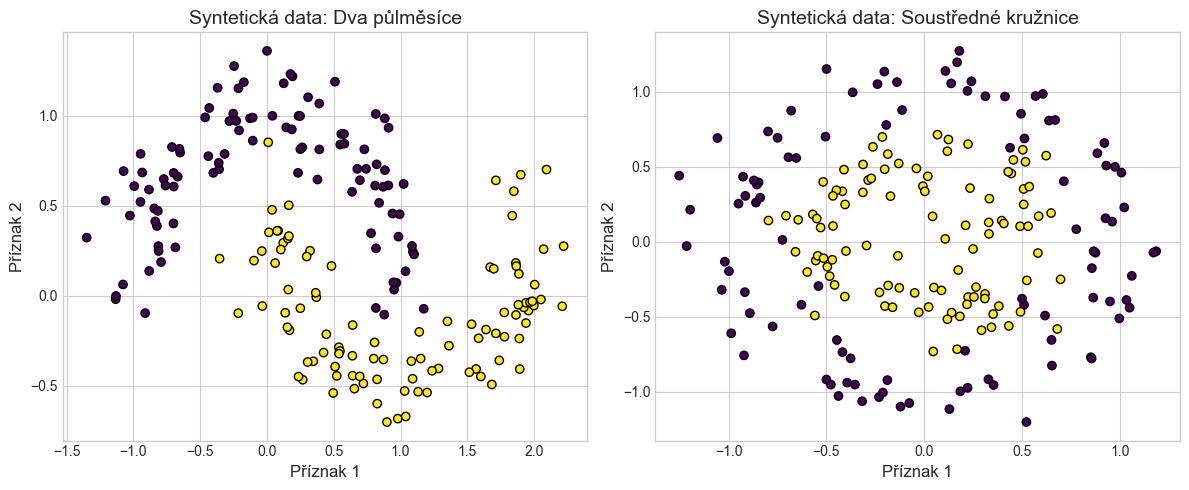

In [14]:
# Vytvoření syntetického datasetu se dvěma příznaky a dvěma třídami
from sklearn.datasets import make_moons, make_circles

# Data ve tvaru dvou půlměsíců
X_moons, y_moons = make_moons(n_samples=200, noise=0.15, random_state=42)

# Data ve tvaru soustředných kružnic
X_circles, y_circles = make_circles(n_samples=200, noise=0.15, factor=0.5, random_state=42)

# Vizualizace syntetických dat
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap=plt.cm.viridis, edgecolor='k')
plt.title('Syntetická data: Dva půlměsíce', fontsize=14)
plt.xlabel('Příznak 1', fontsize=12)
plt.ylabel('Příznak 2', fontsize=12)

plt.subplot(1, 2, 2)
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap=plt.cm.viridis, edgecolor='k')
plt.title('Syntetická data: Soustředné kružnice', fontsize=14)
plt.xlabel('Příznak 1', fontsize=12)
plt.ylabel('Příznak 2', fontsize=12)

plt.tight_layout()
plt.show()

## 12. Ukázka SVC na syntetických datech

Podívejme se, jak si SVC s různými jádry poradí s lineárně neoddělitelnými syntetickými daty.

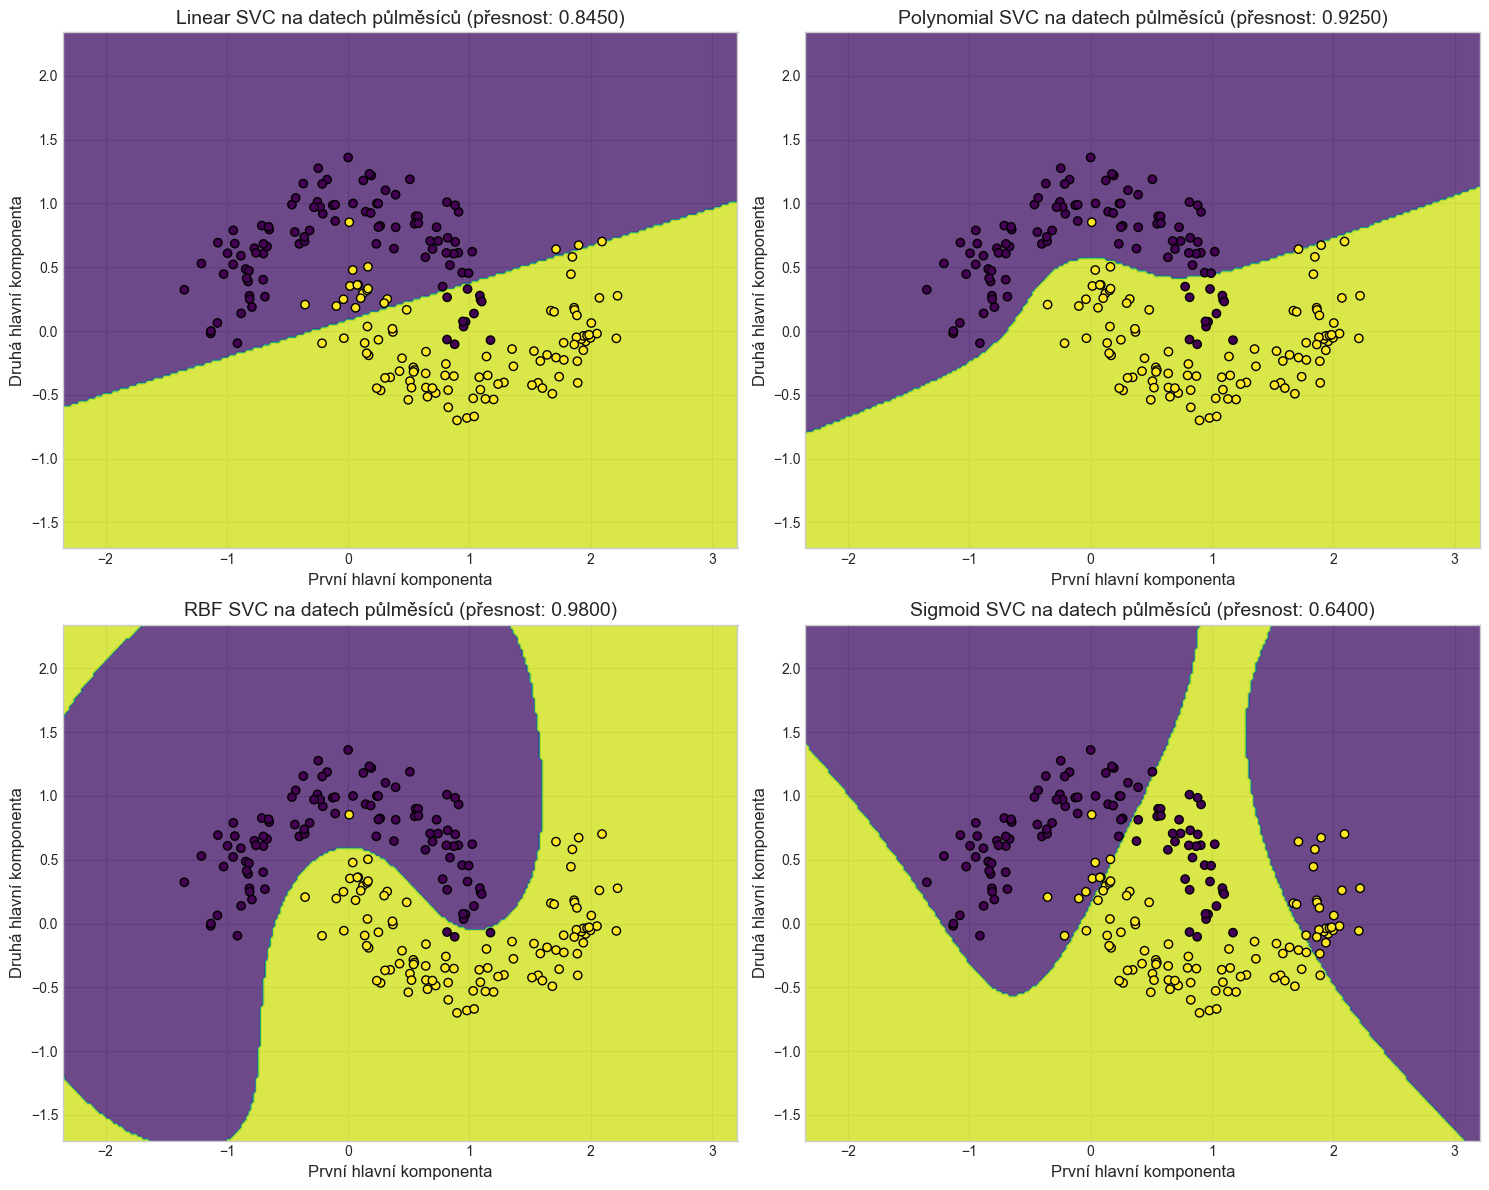

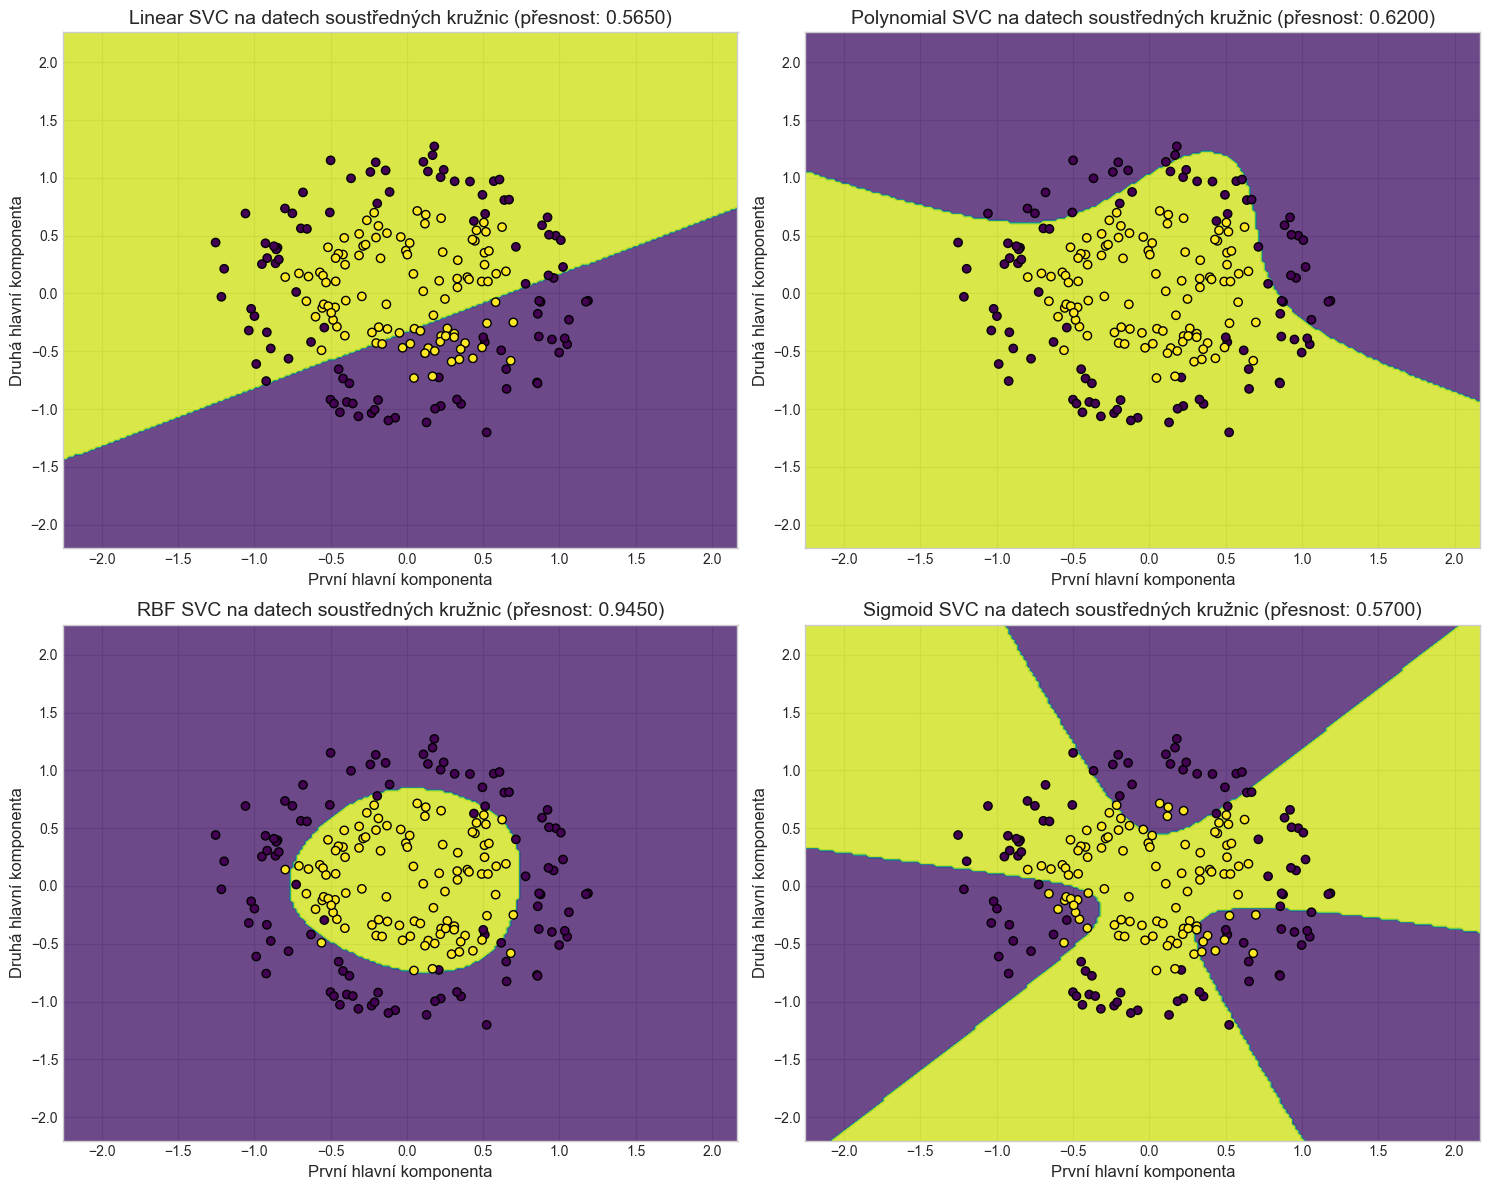

In [15]:
# Definice různých konfigurací SVC pro testování
svc_configs = [
    ('Linear SVC', SVC(kernel='linear', C=1.0)),
    ('Polynomial SVC', SVC(kernel='poly', C=1.0, degree=3, gamma='scale')),
    ('RBF SVC', SVC(kernel='rbf', C=1.0, gamma='scale')),
    ('Sigmoid SVC', SVC(kernel='sigmoid', C=1.0, gamma='scale'))
]

# Funkce pro vizualizaci rozhodovacích hranic na syntetických datech
def visualize_synthetic_data(X, y, title_prefix):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, (name, model) in enumerate(svc_configs):
        model.fit(X, y)
        accuracy = model.score(X, y)
        ax = axes[i]
        plot_decision_boundaries(X, y, model, f"{name} na {title_prefix} (přesnost: {accuracy:.4f})", ax=ax)
    
    plt.tight_layout()
    plt.show()

# Vizualizace pro data půlměsíců
visualize_synthetic_data(X_moons, y_moons, "datech půlměsíců")

# Vizualizace pro data soustředných kružnic
visualize_synthetic_data(X_circles, y_circles, "datech soustředných kružnic")

## 13. Praktické tipy pro použití SVC

### Tipy pro optimální použití SVC:

1. **Standardizace dat**: SVC je citlivý na měřítko příznaků. Vždy standardizujte data před použitím SVC.

2. **Výběr jádra**:
   - **Linear**: Pro lineárně oddělitelná data nebo vysoko-dimenzionální data
   - **RBF**: Výchozí volba, vhodná pro většinu případů
   - **Polynomial**: Pro data, která vyžadují křivky vyšších řádů
   - **Sigmoid**: Méně často používané, chová se podobně jako neuronová síť

3. **Ladění parametrů**:
   - **C**: Začněte s C=1 a pak zkuste dekadické hodnoty (0.1, 10, 100)
   - **gamma** (pro RBF): Začněte s 'scale' a pak zkuste konkrétní hodnoty
   - **degree** (pro polynomiální): Začněte s 3, obvykle hodnoty nad 5 vedou k přeučení

4. **Velikost datasetu**: Pro velké datasety (>10,000 vzorků) zvažte použití LinearSVC nebo SGDClassifier, které jsou efektivnější.

5. **Nevyváženost tříd**: V případě nevyvážených tříd použijte parametr `class_weight='balanced'` nebo `class_weight` slovník.

6. **Interpretace**: Podpůrné vektory mohou být užitečné pro interpretaci – reprezentují nejdůležitější vzorky, které definují rozhodovací hranici.

7. **Škálování na velká data**: Pro větší datasety zkuste použít SGDClassifier s `loss='hinge'`, který aproximuje lineární SVC pro velký počet vzorků.

## 14. Praktické použití SVC na reálném problému

Podívejme se na praktické použití SVC pro klasifikaci a ukažme si, jak bychom mohli vytvořit funkci pro predikci na nových datech.

In [16]:
# Vytvoření finálního modelu s nejlepšími parametry
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel=best_kernel, C=best_C, gamma=best_gamma, probability=True, random_state=42))
])

# Trénování finálního modelu na celém datasetu
final_model.fit(X, y)

# Funkce pro predikci na nových datech
def predict_cancer(features, return_probability=False):
    """
    Funkce pro predikci na nových datech.
    
    Parametry:
    features -- vektor příznaků nebo matice příznaků pro více vzorků
    return_probability -- pokud True, vrací také pravděpodobnosti tříd
    
    Vrací:
    predicted_class -- predikovaná třída (0=benigní, 1=maligní)
    probability -- (volitelné) pravděpodobnost, že vzorek patří do třídy maligní
    """
    # Zajištění správného tvaru vstupu
    features = np.array(features).reshape(1, -1) if len(np.array(features).shape) == 1 else np.array(features)
    
    # Predikce
    predicted_class = final_model.predict(features)
    
    if return_probability:
        probability = final_model.predict_proba(features)[:, 1]  # Pravděpodobnost třídy 1 (maligní)
        return predicted_class, probability
    else:
        return predicted_class

# Demonstrace použití funkce
# Použijeme několik vzorků z testovacího datasetu
sample_data = X_test[:5]  # Prvních 5 vzorků z testovacích dat

# Predikce bez pravděpodobností
predictions = predict_cancer(sample_data)
print("Predikce (0=benigní, 1=maligní):")
print(predictions)

# Predikce s pravděpodobnostmi
predictions, probabilities = predict_cancer(sample_data, return_probability=True)
print("\nPredikce s pravděpodobnostmi:")
for i in range(len(predictions)):
    predicted_class = "Maligní" if predictions[i] == 1 else "Benigní"
    print(f"Vzorek {i+1}: {predicted_class} (pravděpodobnost maligní: {probabilities[i]:.4f})")

# Porovnání se skutečnými třídami
print("\nSkutečné třídy:")
for i in range(5):
    actual_class = "Maligní" if y_test[i] == 1 else "Benigní"
    print(f"Vzorek {i+1}: {actual_class}")

Predikce (0=benigní, 1=maligní):
[1 0 1 1 0]

Predikce s pravděpodobnostmi:
Vzorek 1: Maligní (pravděpodobnost maligní: 0.9772)
Vzorek 2: Benigní (pravděpodobnost maligní: 0.0008)
Vzorek 3: Maligní (pravděpodobnost maligní: 0.5816)
Vzorek 4: Maligní (pravděpodobnost maligní: 0.9708)
Vzorek 5: Benigní (pravděpodobnost maligní: 0.1785)

Skutečné třídy:
Vzorek 1: Maligní
Vzorek 2: Benigní
Vzorek 3: Maligní
Vzorek 4: Maligní
Vzorek 5: Benigní


## 15. Závěr

V tomto notebooku jsme prozkoumali Support Vector Classifier (SVC) a jeho aplikace na reálná data. Zde jsou hlavní poznatky:

### Shrnutí

1. **SVC je výkonný klasifikační algoritmus** schopný řešit lineární i nelineární klasifikační problémy díky jádrovému triku.

2. **Výběr správného jádra je klíčový** - RBF jádro je obecně dobrou výchozí volbou, ale lineární jádro může být lepší pro vysokodimenzionální data.

3. **Parametry C a gamma významně ovlivňují výkon modelu** - C kontroluje kompromis mezi hladkou hranicí a chybou klasifikace, gamma určuje dosah vlivu trénovacích bodů.

4. **Standardizace dat je kritická** pro dobrý výkon SVC, protože algoritmus je citlivý na měřítko příznaků.

5. **SVC vykazuje vynikající výkon** na mnoha datových sadách, zejména když jsou data nelineární a ne příliš velká.

### Kdy použít SVC

- Pro datové sady střední velikosti (do ~10,000 vzorků)
- Když potřebujete robustní klasifikaci s dobrou generalizací
- Pro problémy s komplexními nelineárními hranicemi mezi třídami
- Když je důležitější přesnost než interpretovatelnost

### Kdy zvážit jiné algoritmy

- Pro velmi velké datasety (použijte LinearSVC nebo SGDClassifier)
- Když je důležitá interpretovatelnost (rozhodovací stromy nebo logistická regrese)
- Pro extrémně vysokodimenzionální problémy s řídkými daty (může být lepší Naive Bayes)

SVC zůstává jedním z nejsilnějších klasifikačních algoritmů v oblasti strojového učení, zejména pro problémy střední velikosti s komplexními rozhodovacími hranicemi.